In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import json
import os

In [3]:
import json

models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]
states   = ["pretrained", "finetuned"]
EMOTIONS = ["anger", "disgust", "joy", "sadness"]

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

print(f"{'Model+State':<25} {'Global Peak':<13} {'Peak F1':<10} {'Anger':<7} {'Disgust':<9} {'Joy':<7} {'Sadness':<9} {'Low-λ Peak':<12} {'High-λ Peak'}")
print("-" * 105)

for model in models:
    for state in states:
        path = f"/Users/harshaggarwal/Projects_4/hinemo_project/models/phase7b_probing_results_emotion_classification_4k/{model}/emotion_classification_probe_{state}.json"
        with open(path) as f:
            r = json.load(f)

        label        = f"{model_short[model]} {state}"
        global_peak  = r["global_peak_layer"]
        global_f1    = r["global_f1_per_layer"][global_peak - 1]
        emotion_peaks = [str(r["peak_layer_per_emotion"][e]) for e in EMOTIONS]
        low_peak     = r["lambda_split"]["low_lambda"]["peak_layer"]
        high_peak    = r["lambda_split"]["high_lambda"]["peak_layer"]

        print(f"{label:<25} {global_peak:<13} {global_f1:<10.4f} "
              f"{emotion_peaks[0]:<7} {emotion_peaks[1]:<9} "
              f"{emotion_peaks[2]:<7} {emotion_peaks[3]:<9} "
              f"{low_peak:<12} {high_peak}")

Model+State               Global Peak   Peak F1    Anger   Disgust   Joy     Sadness   Low-λ Peak   High-λ Peak
---------------------------------------------------------------------------------------------------------
mBERT pretrained          4             0.4931     1       4         3       3         5            1
mBERT finetuned           12            0.6151     12      12        12      12        10           11
MuRIL pretrained          10            0.5510     10      10        9       7         6            8
MuRIL finetuned           12            0.6729     12      10        12      12        12           11
XLM-R pretrained          6             0.6241     10      12        6       12        12           12
XLM-R finetuned           12            0.7613     12      12        12      12        12           12


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

BASE_PATH = "/Users/harshaggarwal/Projects_4/hinemo_project/models"
SAVE_DIR  = f"{BASE_PATH}/figures/phase7b_emotion_classification_probing_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]
states   = ["pretrained", "finetuned"]
EMOTIONS = ["anger", "disgust", "joy", "sadness"]
layers   = list(range(1, 13))

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

model_colors = {
    "bert-base-multilingual-cased": "#3498db",
    "muril-base-cased"            : "#2ecc71",
    "xlm-roberta-base"            : "#e74c3c"
}

emotion_colors = {
    "anger"  : "#e74c3c",
    "disgust": "#9b59b6",
    "joy"    : "#f39c12",
    "sadness": "#3498db"
}

bucket_colors = {
    "low_lambda" : "#3498db",
    "high_lambda": "#e74c3c"
}

bucket_labels = {
    "low_lambda" : "Low-λ English-dominant",
    "high_lambda": "High-λ Hindi-dominant"
}

# Load all 6 results
results = {}
for model in models:
    for state in states:
        path = f"{BASE_PATH}/phase7b_probing_results_emotion_classification_4k/{model}/emotion_classification_probe_{state}.json"
        with open(path) as f:
            results[(model, state)] = json.load(f)

print("Loaded all 6 combinations.")
for key in results:
    r = results[key]
    print(f"  {model_short[key[0]]} {key[1]:<12} peak=L{r['global_peak_layer']}  F1={r['global_f1_per_layer'][r['global_peak_layer']-1]:.4f}")

Loaded all 6 combinations.
  mBERT pretrained   peak=L4  F1=0.4931
  mBERT finetuned    peak=L12  F1=0.6151
  MuRIL pretrained   peak=L10  F1=0.5510
  MuRIL finetuned    peak=L12  F1=0.6729
  XLM-R pretrained   peak=L6  F1=0.6241
  XLM-R finetuned    peak=L12  F1=0.7613


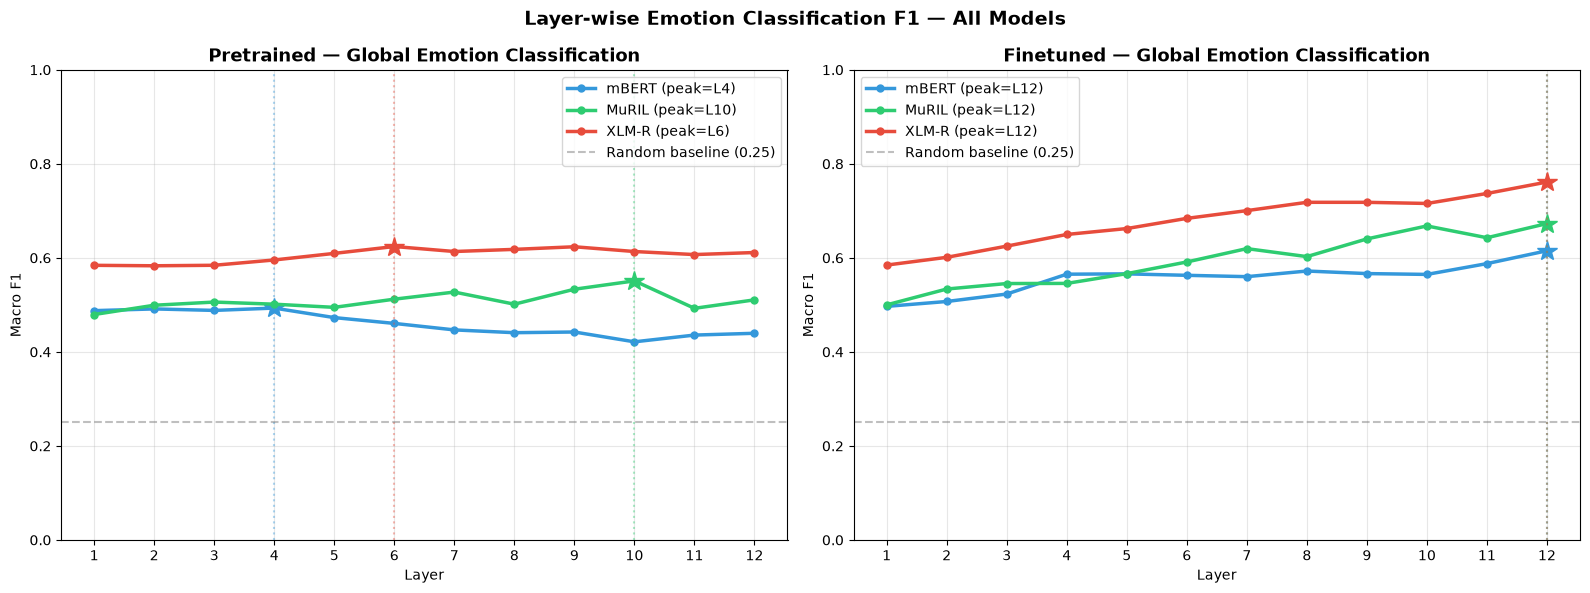

Saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col, state in enumerate(states):
    ax = axes[col]

    for model in models:
        r        = results[(model, state)]
        f1_curve = r["global_f1_per_layer"]
        peak     = r["global_peak_layer"]

        ax.plot(layers, f1_curve,
                label=f"{model_short[model]} (peak=L{peak})",
                color=model_colors[model],
                linewidth=2.5,
                marker="o",
                markersize=5)

        ax.axvline(x=peak,
                   color=model_colors[model],
                   linestyle=":",
                   alpha=0.4)

        ax.plot(peak, f1_curve[peak-1],
                marker="*",
                color=model_colors[model],
                markersize=15)

    # Random baseline for 4-class problem
    ax.axhline(y=0.25,
               color="gray",
               linestyle="--",
               alpha=0.5,
               label="Random baseline (0.25)")

    ax.set_title(f"{state.capitalize()} — Global Emotion Classification",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Macro F1")
    ax.set_xticks(layers)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Emotion Classification F1 — All Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig1_global_f1_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

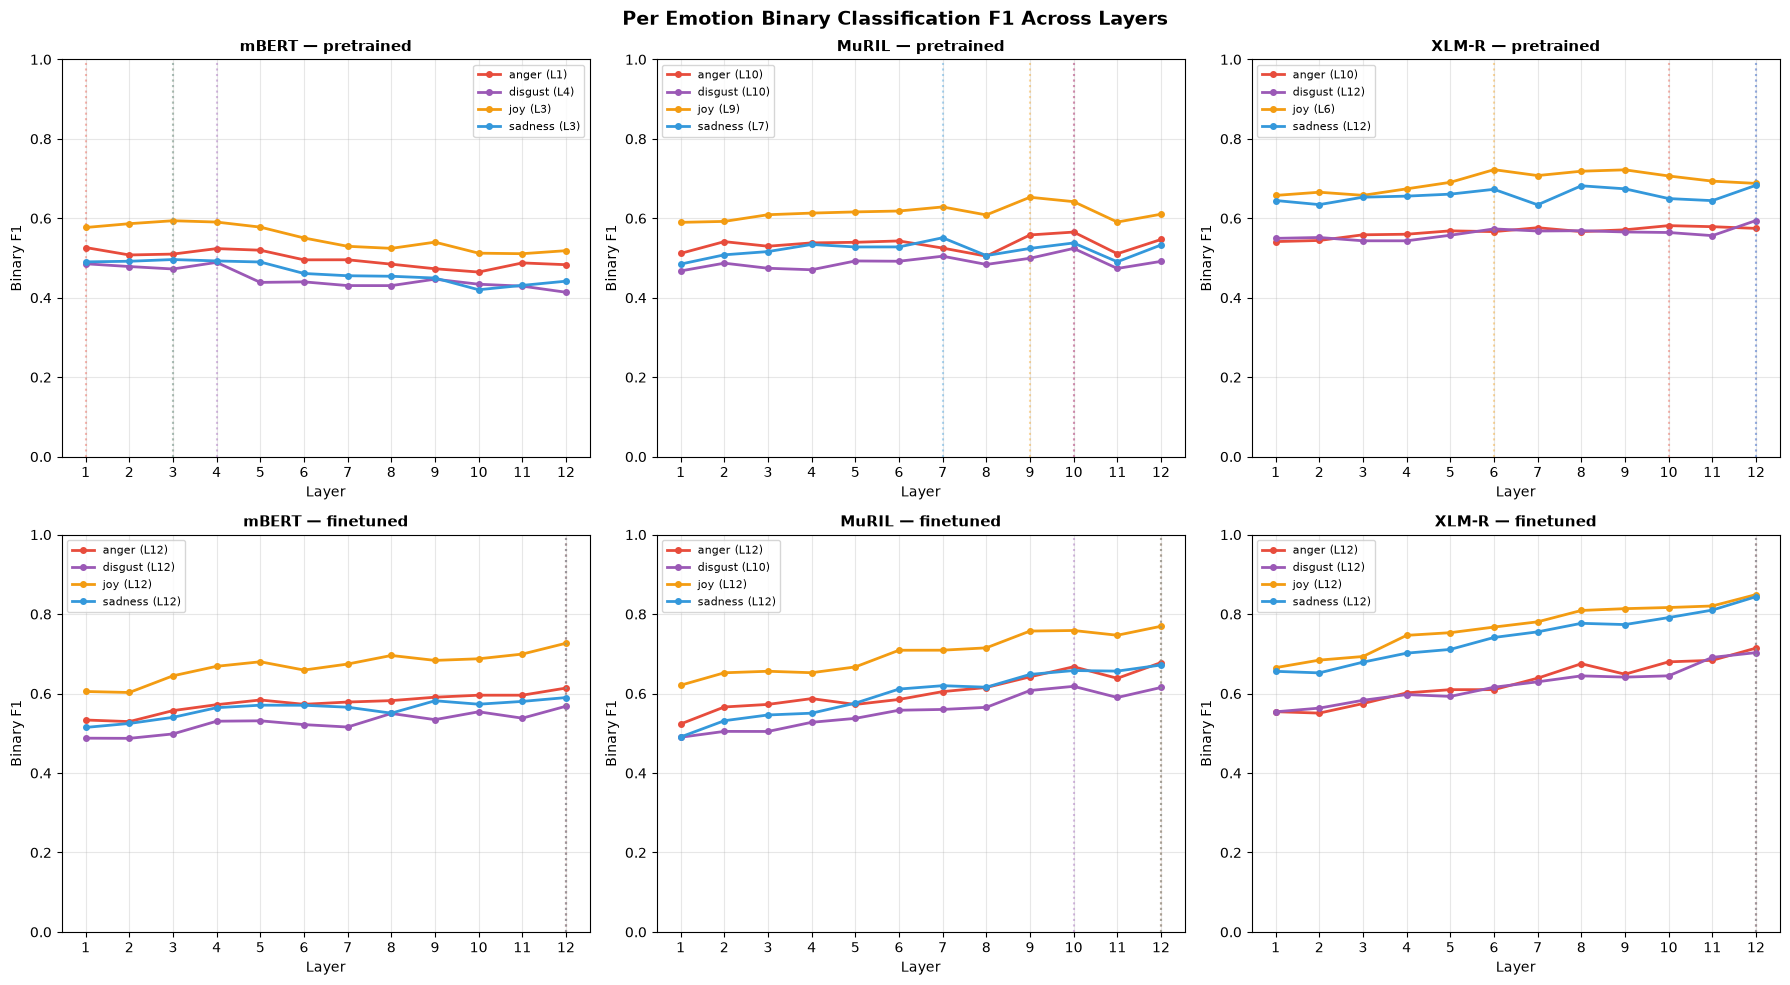

Saved.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax = axes[row, col]
        r  = results[(model, state)]

        for emotion in EMOTIONS:
            f1_curve = r["binary_f1_per_emotion"][emotion]
            peak     = r["peak_layer_per_emotion"][emotion]

            ax.plot(layers, f1_curve,
                    label=f"{emotion} (L{peak})",
                    color=emotion_colors[emotion],
                    linewidth=2,
                    marker="o",
                    markersize=4)

            ax.axvline(x=peak,
                       color=emotion_colors[emotion],
                       linestyle=":",
                       alpha=0.4)

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Binary F1")
        ax.set_xticks(layers)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Per Emotion Binary Classification F1 Across Layers",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig2_per_emotion_f1_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

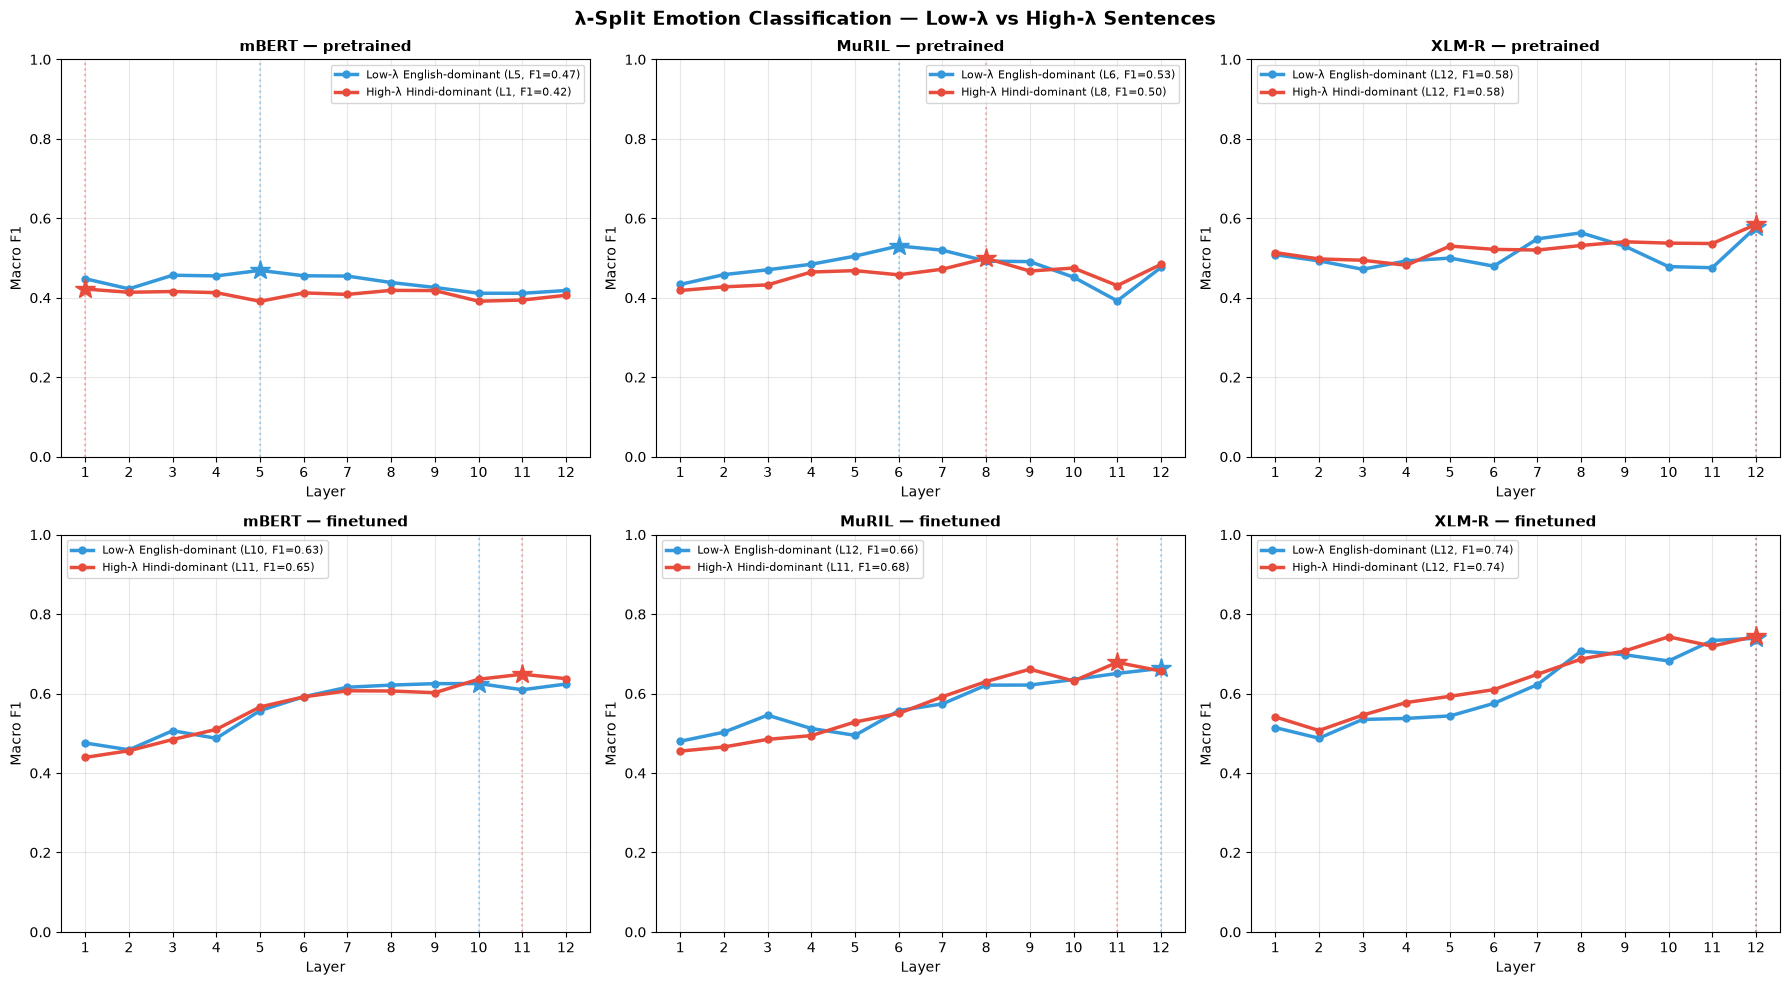

Saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax = axes[row, col]
        r  = results[(model, state)]

        for bucket in ["low_lambda", "high_lambda"]:
            f1_curve = r["lambda_split"][bucket]["f1_per_layer"]
            peak     = r["lambda_split"][bucket]["peak_layer"]
            peak_f1  = r["lambda_split"][bucket]["peak_f1"]

            ax.plot(layers, f1_curve,
                    label=f"{bucket_labels[bucket]} (L{peak}, F1={peak_f1:.2f})",
                    color=bucket_colors[bucket],
                    linewidth=2.5,
                    marker="o",
                    markersize=5)

            ax.axvline(x=peak,
                       color=bucket_colors[bucket],
                       linestyle=":",
                       alpha=0.4)

            ax.plot(peak, f1_curve[peak-1],
                    marker="*",
                    color=bucket_colors[bucket],
                    markersize=15)

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Macro F1")
        ax.set_xticks(layers)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("λ-Split Emotion Classification — Low-λ vs High-λ Sentences",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig3_lambda_split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

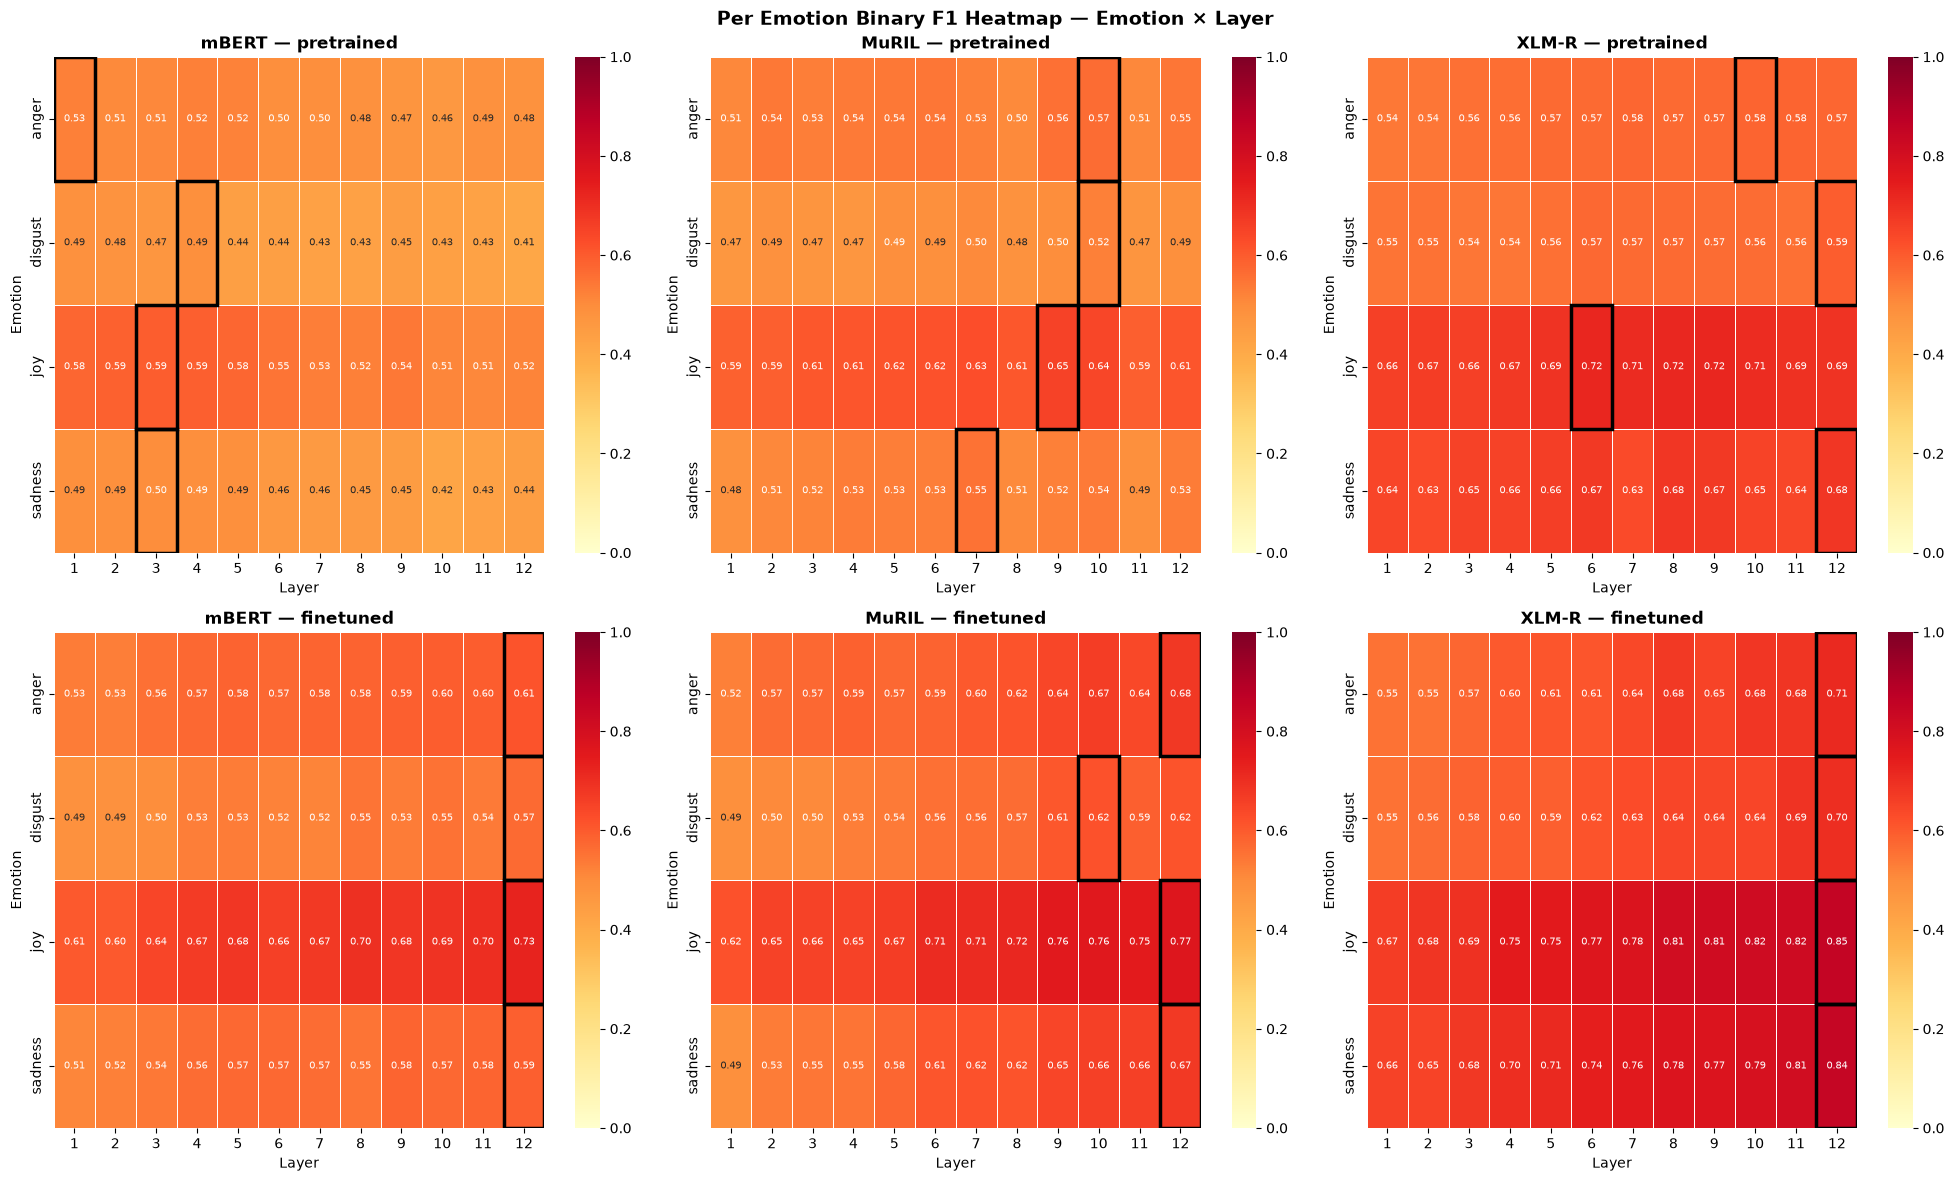

Saved.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax = axes[row, col]
        r  = results[(model, state)]

        # Build matrix: rows=emotions, cols=layers
        matrix = np.array([
            r["binary_f1_per_emotion"][emotion] for emotion in EMOTIONS
        ])  # shape: (4, 12)

        sns.heatmap(
            matrix,
            ax=ax,
            vmin=0,
            vmax=1,
            cmap="YlOrRd",
            xticklabels=[str(l) for l in layers],
            yticklabels=EMOTIONS,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            linewidths=0.5,
            linecolor="white",
            cbar=True
        )

        # Black box around LSL for each emotion
        for e_idx, emotion in enumerate(EMOTIONS):
            peak = r["peak_layer_per_emotion"][emotion]
            ax.add_patch(plt.Rectangle(
                (peak-1, e_idx), 1, 1,
                fill=False,
                edgecolor="black",
                lw=2.5
            ))

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Emotion")

plt.suptitle("Per Emotion Binary F1 Heatmap — Emotion × Layer",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig4_emotion_layer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")